# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

# <h1><center>Tarea 02: Extracción y Transformación de Datos </center></h1>

**Fecha de Entrega:** 25 de septiembre de 2025, a las 23:59.

**Fecha de publicación**: 2 de septiembre de 2025.

**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 02 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tarea.

- Deben hacer sus consultas y comentarios sobre la Tarea a través del canal de Tareas en el Foro del curso en Canvas.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

Para esta tarea, queremos comprender y visualizar la distribución de aves migratorias en el territorio chileno. Específicamente, queremos entender las diferencias entre las migraciones de 2 especies en particular, el run-run y la dormilona tontita, a partir de los avistamientos registrados en eBird durante un periodo de 3 años y medio.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

### 1.4 Ejemplo de visualización

Esta tarea se enfoca en datos de aves. Para complementarla, les compartimos la siguiente página web, llamada "Bird Migration Explorer" que les permite visualizar, de una forma novedosa e interesante, las rutas de migración de aves en las Americas. Visiten la página para que vean cómo se puede visualizar datos de una manera interesante y novedosa, que podría ustedes usar en el futuro para sus proyectos.

In [48]:
from IPython.display import IFrame
IFrame("https://explorer.audubon.org/home?layersPanel=expand", width=900, height=600)

## 2. Datos

Los datos a utilizar provienen de la plataforma **[eBird](https://ebird.org/)**, una aplicación desarrollada por The Cornell Lab of Ornithology que permite a sus usuarios registrar y compartir avistamientos de aves en todo el mundo. La plataforma dispone de una API mediante la cual se pueden realizar consultas sobre avistamientos de aves recientes e históricos, especies según región, taxonomía, entre otros. 

### 2.1 Acceso a la API

Muchas API pueden utilizarse solo mediante el uso de una clave única, o "API key". Para conseguir una API key en eBird, primero debe ser usuario de la plataforma. Puede crear una cuenta aquí: https://secure.birds.cornell.edu/identity/account/create


Con una cuenta ya creada, puede ingresar a https://ebird.org/api/keygen para generar su llave. Debe llenar un formulario de solicitud al pedir su llave. Como sugerencia, puede llenar los campos con la siguiente información:

* **Organización:** Pontificia Universidad Católica de Chile
* **Título del Proyecto:** Tarea IMT2200 Introducción a Ciencia de Datos
* **Descripción:** "Uso educativo para exploración y análisis de distribución de aves migratorias en Chile."
* **Tipo de Proyecto:** Academic/Student
* **Casos de uso:** Materiales educativos y artíticos (...)

Debería recibir su llave inmediatamente después de enviar su solicitud. Como recomendación, puede revisar la documentación de la API en el siguiente link: https://documenter.getpostman.com/view/664302/S1ENwy59#intro

#### 2.2 Mapoteca de BCN

Para esta tarea queremos visualizar el movimiento de aves a lo largo de nuestro país. Para ello, también necesitaremos manejar datos geoespaciales: específicamente, trabajaremos con un mapa vectorial de Chile disponible en la página web de la Biblioteca del Congreso Nacional: https://www.bcn.cl/siit/mapas_vectoriales/index_html

Descargue el archivo `.zip` para las **Divisiones regionales** y descomprímalo. Dentro de esta carpeta, habrá un archivo llamado `Regional.shp`, que utilizaremos con `geopandas` para graficar nuestro mapa de Chile.

### 2.3 Librerías

Para esta tarea recomendamos al menos usar las librerías indicadas en la siguiente celda del Notebook. Puede agregar otras si lo estima conveniente para responder de mejor forma las preguntas de la Tarea.

In [49]:
import requests
import datetime
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

## 3. Desarrollo

Para cada una de las siguientes preguntas o actividades incluya una o más celdas de código y Markdown con las respuestas o comentarios necesarios para contestar la pregunta o lograr la actividad. Agregue sus celdas a continuación de cada pregunta para que el Notebook quede ordenado.

En el caso de gráficos, figuras o tablas, asegúrese que todas tengan título, etiquetas en los ejes o haya claridad de los contenidos.

### 3.1 Extracción de datos (1.5 puntos)

**(1 pto)** Vamos a crear nuestra base de datos con los avistamientos registrados en eBird dentro de Chile desde 2022 hasta 2025. Revise la documentación de la API y averigue cómo extraer los avistamientos de un día. Luego extraiga los avistamientos para todos los días desde el **1 de enero de 2022 hasta el 31 de julio de 2025.** Cuando haya logrado extraer todos los datos, guárdelos en un archivo CSV o parquet.

Responda:

**a) (0.2 pts)** ¿Cuántos avistamientos tiene su dataset?

**b) (0.3 pts)** Obtenga la cantidad de veces que se repite cada especie en su dataset y ordénelas de mayor a menor. ¿Qué pasa con la cantidad de avistamientos según especie? ¿Por qué?

**Recomendaciones:** 
* Puede usar la librería `datetime` para generar fechas: cree una lista con todas las fechas e itere sobre esta lista para hacer los llamados a la API.
* **Pruebe primero con uno o dos días** para verificar el funcionamiento de su código y de la API.
* Inspeccione la forma en la que vienen los datos.
* Vaya guardando los datos extraídos en archivos (CSV o parquet), de modo que no tenga que repetir los llamados en caso de algún error.

**Hint**: Los códigos regionales chilenos para la API son los siguientes,
* `regionCode = CL`
* `sppLocale = es_CL` (para obtener nombres chilenos de las aves)

In [6]:
llave = "o2infsq47v5m"
inicio = datetime.date(2022,1,1)
fin = datetime.date(2025,7,31)
pajaros = []

rango = (fin -inicio).days
fechas = []
for i in range(rango):
    dias = inicio + datetime.timedelta(days=i)
    fechas.append(dias)
# la idea es , puesto que en la documentacion solo sale que se puede extraer hasta 30 dias usando 
#el comando back, hacer una extraccion de cada dia, guardarla en un json, que es lo que recibe
#el request.get, y posterior  a eso volverlo todo un dataframe
for fecha_actual in fechas:
    url = f"https://api.ebird.org/v2/data/obs/CL/historic/{fecha_actual.year}/{fecha_actual.month}/{fecha_actual.day}?spplocale=es_CL"  
    api = {"X-eBirdApiToken" : llave}
    try:
        respuesta = requests.get(url , headers = api , timeout= 30)
        if respuesta.status_code == 200:
            datos = respuesta.json()
            if datos:
                pajaros.extend(datos)
    
    except requests.exceptions.RequestException as e:
        print(f"error en {fecha_actual} :{e}")    
dataframe = pd.DataFrame(pajaros)
dataframe.to_csv("dataframe_analisis_IMT2200.csv", index = False , encoding="utf-8-sig")


dataframe.head()


,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng,obsValid,obsReviewed,locationPrivate,subId,exoticCategory
0,soulap1,Southern Lapwing,Vanellus chilensis,L10140471,"Villa Parque Austral, Osorno, Región de los La...",2022-01-01 23:41,3.0,-40.585844,-73.113157,True,False,True,S99916680,NaN
1,bkfibi1,Black-faced Ibis,Theristicus melanopis,L7988120,"Leñadura, Nuestra casa",2022-01-01 22:18,4.0,-53.214573,-70.947665,True,False,True,S100024876,NaN
2,grhowl2,Lesser Horned Owl,Bubo magellanicus,L7988120,"Leñadura, Nuestra casa",2022-01-01 22:18,1.0,-53.214573,-70.947665,True,False,True,S100024876,NaN
3,austhr1,Austral Thrush,Turdus falcklandii,L7988120,"Leñadura, Nuestra casa",2022-01-01 22:18,1.0,-53.214573,-70.947665,True,False,True,S100024876,NaN
4,rucspa1,Rufous-collared Sparrow,Zonotrichia capensis,L7988120,"Leñadura, Nuestra casa",2022-01-01 22:18,2.0,-53.214573,-70.947665,True,False,True,S100024876,NaN


In [ ]:
dataframe = pd.read_csv("dataframe_analisis_IMT2200.csv")
#para que no demore 40 minutos en cargar cada ves que reinicie el jupyter notebook
dataframe = dataframe.drop_duplicates()

dataframe = dataframe[dataframe["howMany"] != 0]

dataframe = dataframe.dropna(subset=["sciName"])
dataframe = dataframe.dropna(subset=["comName"])
dataframe = dataframe[dataframe["sciName"] != ""]
dataframe = dataframe[dataframe["comName"] != ""]

#dataframe = dataframe[dataframe["comName"].isinstance(str)]
#dataframe = dataframe[dataframe["sciName"].isinstance( str)]


#se que se puede hacwer con lamda, pero no se si esta permitido, por eso hare un ciclo for para esto
#de todas formas con lamda y instance creo que se podria mas comodamente, idk

datos_filtro = dataframe["comName"]
for i in datos_filtro:
    if type(i) == str :
        pass
    else:
        dataframe.drop(i)

datos_filtro2 = dataframe["sciName"]
for i in datos_filtro2:
    if type(i) == str:
        pass
    else:
        dataframe.drop(i)


#tambien eliminar datos donde nombre cientifico y nombre normal sean NAN  //7 hecho

print(dataframe["sciName"].isna().sum())
print(dataframe["comName"].isna().sum())
#al ambos ser 0 se hizo limpieza encargandonos de que los nombres de las aves sean un 
sciname_cantidad_nostr = 0 #reinventare la rueda de sum solo porque me dio error en un caso 
comName_cantidad_nostr = 0 
for i in datos_filtro:
    if type(i) != str:
        i += 1
    else:
        pass

for j in datos_filtro2:
    if type(i) != str:
        j+= 1
    else:
        pass

print("cantidad de datos distintos a str sciaAme" , sciname_cantidad_nostr)
print("cantidad de datos distintos a str conName" , comName_cantidad_nostr)

#limpieza de datos


0
0
cantidad de datos distintos a str sciaAme 0
cantidad de datos distintos a str conName 0


In [51]:
from IPython.display import display, HTML #todo lo hecho con html fue hecho con ayuda de IA
#de IA, el link esta en otro comentario delc
print("cantidad de avistamientos:" , dataframe["comName"].shape[0])
#solo para mantener un orden
print()
#usaremos el nombre cientifico
#como otros nombres es mas probable que varien en forma de decirse 
#o escritura, se confiara mas en este para hacer el ordenamiento, puesto que
#suele seguir un estandar

datos = dataframe.sort_values(by=["howMany"], ascending=[False]) 


dataframe_nuevo = datos[["sciName" , "howMany"]]
#tenemos un nuevo dataframe
#el cual usaremos para trabajar, este posee
#unicamente los elementos a usar, esto para hacer mas sensilla la operacion
conteo = dataframe_nuevo.groupby("sciName").size()

total = dataframe_nuevo.groupby("sciName")["howMany"].sum()

total_df = pd.concat([total , conteo] , axis = 1)
total_df = total_df.rename(columns={0 : "total_conteo"})


total_df = total_df.sort_values(by = "total_conteo" , ascending= False )

total_df = total_df.rename(columns= {"howMany" : "cantidad_aves"})

mayores = total_df.nlargest(n=10  ,columns= "cantidad_aves")
menores = total_df.nsmallest(n=10  ,columns= "cantidad_aves") 
moda = total_df["total_conteo"].mode()





#el siguiente codigo esta hecho mayormente con IA[https://g.co/gemini/share/280ea1a320b6] ese es el link




html_str = f"""
<div style="display: flex;">
  <div style="padding-right: 30px;">
    <h3>10 mayores en relacion al conteo</h3>
    {mayores.to_html()}
  </div>
  <div style="padding-right: 30px;">
    <h3>10 menores en relacion al conteo</h3>
    {menores.to_html()}

  </div>
</div> 
"""
display(HTML(html_str))


total_df.head(300)




cantidad de avistamientos: 272026



,cantidad_aves,total_conteo
sciName,,
Ardenna grisea,474954.0,1062
Calidris alba,138741.0,966
Leucocarbo bougainvilliorum,129485.0,1159
Limosa haemastica,123567.0,1125
Leucophaeus modestus,118916.0,1297
Leucocarbo atriceps,100965.0,1302
Enicognathus leptorhynchus,97672.0,1293
Leucophaeus pipixcan,87264.0,888
Rynchops niger,65654.0,1238


,cantidad_aves,total_conteo
sciName,,
Zonotrichia capensis,3603.0,1307
Zenaida meloda,4673.0,1307
Anairetes parulus,2453.0,1307
Myiopsitta monachus,6829.0,1307
Zenaida auriculata,6013.0,1307
...,...,...
Calidris melanotos,519.0,224
Halobaena caerulea,1450.0,223
Diglossa brunneiventris,404.0,223


#### Respuesta Apartado 3.1 a)
el Dataset tiene 272026 Avistamientos en total

#### Respuesta Apartado 3.1 b)
Se puede observar una tendencia a que , cuando se tienen menos obseravaciones de aves tambien se tenga una menor cantidad total de aves, aunque esta misma no es una regla estricta , si es una tendencia general que se sigue en los datos del dataframe, esto puede suceder puesto que se tiene una tendencia a que, al tener mas observaciones, sean aves mucho mas comunes, tambien significando que sea mas probable verlos en grupo


### 3.2 Tranformación (1 punto)

**a) (0.5 pts)** Transforme la columna `obsDt` de string a un objeto de tipo `datetime` únicamente con año, mes y día (YYYY-MM-DD). Luego, agregue las siguientes nuevas columnas:
* `month` con únicamente el mes del avistamiento (puede dejar el mes como número entero de 1 a 12).
* `year-month` con el mes y año fecha en formato YYYY-MM

In [52]:
#Importante leer esto
#en el momento de hacer codigo, no lo hice pero la columna se podria haber tranformado con el medotod
# to_datetime, de la forma
#pd.to_datetime(datos["obsDt"]) de todas formas
#el codigo que poseo ya es funcional, y personalmente me sirvio mas
#para aprender que haber ejecutado el codigo anterior, espero no haya problemas por no hacerlo de la forma
#mas optima, dejando en claro que para siguientes tareas ya se como hacerlo mejor


#idea, iterar para obtener una lista con las fechas, luego se hace el cambio
fecha_string = datos["obsDt"]
fecha = []

for i in fecha_string:
    fecha.append(i)

#tenemos las fechas como string  y las transformaremos en datetimes que se guardan
fecha_total = []
month = []
year_month = []
j = 0
for fecha_actual in fecha:
    try:
        fecha_actual = fecha_actual.split("-")
        fecha_actual.extend((fecha_actual.pop()).split(" "))
        año = int(fecha_actual[0])
        mes = int(fecha_actual[1])
        dia = int(fecha_actual[2])

        fecha_total.append(datetime.datetime(año , mes , dia))
        month.append((mes))
        year_month.append(datetime.datetime(año , mes , 1))
        # el 1 es puesto que datetime requiere tambien dia
        # por lo que entendi del enunciado debe ser si o si un objeto datetime
        #si solo se preocupa por lo visual se podria guardar como un string haciendo
        # year_month.append(f"{año}-{mes}") 
    except Exception as error:
        j += 1
        print(f"error {j},{fecha_actual} , error:{error}")

#hubieron muchos errores por equivocarme en algo 
datos["obsDt"] = fecha_total
datos["month"] = month
datos["year-month"] = year_month

datos["obsDt"].info()

#como estamos modificando el datadframe, al volver a ejecutar esta misma selda puede dar error
datos.columns

<class 'pandas.core.series.Series'>
Index: 272026 entries, 235366 to 271938
Series name: obsDt
Non-Null Count   Dtype         
--------------   -----         
272026 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 4.2 MB


Index(['speciesCode', 'comName', 'sciName', 'locId', 'locName', 'obsDt',
       'howMany', 'lat', 'lng', 'obsValid', 'obsReviewed', 'locationPrivate',
       'subId', 'exoticCategory', 'month', 'year-month'],
      dtype='object')

**b) (0.5 pts)** Averigue cómo tranformar su DataFrame de Pandas en un GeoDataFrame de GeoPandas. Para esto, utilice las columnas `lat`y `lng` para generar los puntos de la nueva columna `geometry`. Para las visualizaciones siguientes utilizaremos el Coordinate Reference System (CRS) EPSG 4326 (también llamado [WGS 84](https://es.wikipedia.org/wiki/WGS84)). Asegúrese que sus coordenadas correspondan a este CRS al crear su GeoDataFrame.

In [53]:
#entiendo que debo de transformar el dataframe de ebird a un geodataframe

geodatos = gpd.GeoDataFrame(datos , geometry = gpd.points_from_xy(datos.lng , datos.lat), crs= "EPSG:4326")
# este codigo esta bien inspirado(por no decir copiado) , en el codigo de geopandas.org, ,mas informacion en el readme

geodatos.head()


,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng,obsValid,obsReviewed,locationPrivate,subId,exoticCategory,month,year-month,geometry
235366,sooshe,Sooty Shearwater,Ardenna grisea,L5410593,Reserva Costera Valdiviana--Colun,2025-02-03,65400.0,-40.079713,-73.643761,True,False,False,S215127006,NaN,2,2025-02-01,POINT (-73.64376 -40.07971)
200806,sooshe,Sooty Shearwater,Ardenna grisea,L20913197,Playa sector Pilicura,2024-09-16,57600.0,-36.113024,-72.809842,True,True,True,S195398399,NaN,9,2024-09-01,POINT (-72.80984 -36.11302)
105613,sooshe,Sooty Shearwater,Ardenna grisea,L25110631,"MIRAMAR SANTO DOMINGO Avenida del Litoral, San...",2023-06-13,54000.0,-33.631644,-71.635009,True,True,True,S141502666,NaN,6,2023-06-01,POINT (-71.63501 -33.63164)
60419,impcor1,Imperial Cormorant,Leucocarbo atriceps,L3438732,MN Los Pingüinos--Isla Magdalena,2022-11-11,50000.0,-52.920237,-70.575957,True,True,False,S122286697,NaN,11,2022-11-01,POINT (-70.57596 -52.92024)
243337,sooshe,Sooty Shearwater,Ardenna grisea,L23503225,Punta Chaihuin,2025-03-08,30000.0,-39.934391,-73.591917,True,False,False,S217352216,NaN,3,2025-03-01,POINT (-73.59192 -39.93439)


### 3.3 Exploración del dataset (1 punto)

**a) (0.3 pts)** Utilice `geopandas` para leer el archivo `Regional.shp` descargado de BCN. Asegúrese de que su CRS sea el mismo que utilizó en la sección anterior.

In [54]:
import os
from pathlib import Path as path
ruta = os.path.join("regiones" , "Regional.shp")
regional = gpd.read_file(ruta , crs= "EPSG:4326")

regional = regional.to_crs("EPSG:4326")

print("CRS del mapa regional:", regional.crs)
print("CRS del geodataframe:", geodatos.crs)


/home/awa/pruebas/vcd/lib/python3.13/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver ESRI Shapefile does not support open option CRS
  return ogr_read(


CRS del mapa regional: EPSG:4326
CRS del geodataframe: EPSG:4326


**b) (0.7 pts)** Grafique un mapa de Chile con todos los avistamientos de su dataset como puntos en el mapa. Comente: ¿Cómo se distribuyen estos avistamientos? ¿Hay lugares en Chile donde haya una menor densidad de datos? ¿Cuáles? 

/tmp/ipykernel_859/3150519872.py:4: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  geodatos.plot(ax = ax ,color="purple", column= geodatos["sciName"] , markersize= geodatos["howMany"] * 0.2 , alpha = 0.01 , legend = True)


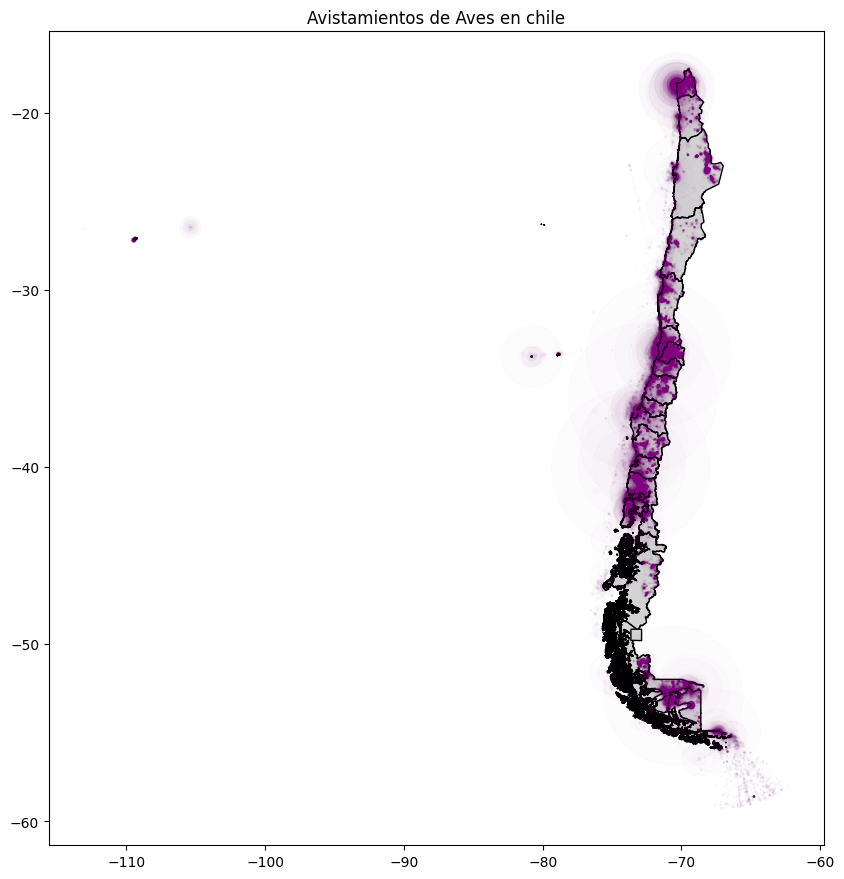

In [55]:
fig , ax = plt.subplots(1 , 1 , figsize = (10, 15))
regional.plot(ax = ax , color = "lightgray" , edgecolor= "black")
ax.set_title("Avistamientos de Aves en chile")
geodatos.plot(ax = ax ,color="purple", column= geodatos["sciName"] , markersize= geodatos["howMany"] * 0.2 , alpha = 0.01 , legend = True)




plt.show()

#quien me mando a intentar hacer el grafico yo y no pedirle a gepeto aaa / (ya si no fue dificil solo que 
#no termino de salir como queria)

#si bien hay una alta cantidad de datos el multiplicarlos por 0.02 permite que el mapa sea visible mostrando las zonas de forma concreta

## Respuesta -->

La distribución de aves se presenta de forma desigual, principalmente enfocadas en zonas mayormente habitadas en Chile, cosa lógica, puesto que estos datos son agregados por civiles, es decir, es más probable que haya una mayor data en el sector donde haya mas personas viviendo, respecto a donde hay una menor densidad de datos entre Antofagasta y Atacama, explicada tanto por el clima arido de la zona como la menor vida civil en ciertas zonas, también, hay una menor cantidad de datos en la región de Los Lagos y sus alrededores, obviamente, tambien hay que especificar, que como se mencionó antes, esta disminucion tambien puede ser por la falta de datos puesto que gente no ha estado subiéndolos.

### 3.4 Visualización de migraciones (2.5 puntos)

**a) (0.2 pts)** Vamos a inspeccionar los avistamientos de las siguientes 2 especies en particular:

* Run-run [(*Hymenops perspicillatus*)](https://www.avesdechile.cl/171.htm)
* Dormilona tontita [(*Muscisaxicola maclovianus*)](https://www.avesdechile.cl/043.htm)

Primero, genere dos nuevos dataframes con los avistamientos de cada especie por separado.

In [56]:
# Respuesta

runrun = datos[datos["sciName"] == "Hymenops perspicillatus"]

dormilona =  datos[datos["sciName"] == "Muscisaxicola maclovianus"]

dormilona.head()



,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng,obsValid,obsReviewed,locationPrivate,subId,exoticCategory,month,year-month
170657,dafgrt1,Dark-faced Ground-Tyrant,Muscisaxicola maclovianus,L12248664,Estancia Vega Castillo,2024-04-07,110.0,-51.297707,-72.659304,True,True,False,S167814622,NaN,4,2024-04-01
257598,dafgrt1,Dark-faced Ground-Tyrant,Muscisaxicola maclovianus,L807764,Las Quemas Altas,2025-05-15,102.0,-40.628448,-73.117919,True,True,False,S238426736,NaN,5,2025-05-01
45433,dafgrt1,Dark-faced Ground-Tyrant,Muscisaxicola maclovianus,L20746542,"X-674, Valle Simpson, Aysén, CL (-45,739, -72,...",2022-09-01,100.0,-45.738502,-72.102449,True,True,True,S117964842,NaN,9,2022-09-01
36776,dafgrt1,Dark-faced Ground-Tyrant,Muscisaxicola maclovianus,L807764,Las Quemas Altas,2022-07-14,94.0,-40.628448,-73.117919,True,False,False,S115071141,NaN,7,2022-07-01
121239,dafgrt1,Dark-faced Ground-Tyrant,Muscisaxicola maclovianus,L27016504,"Hoyería, Puyehue, (-40.657, -72.272)",2023-09-09,86.0,-40.656848,-72.271534,True,False,True,S149495212,NaN,9,2023-09-01


**b) (0.8 pts)** Para cada una de estas especies, agrupe los datos según `year-month`. Luego, realice un gráfico que muestre la cantidad de avistamientos en el tiempo, empezando desde enero del 2022 hasta julio de 2025. Responda: ¿cómo varía cantidad de avistamientos para estas dos especies? ¿Cuáles son sus diferencias?

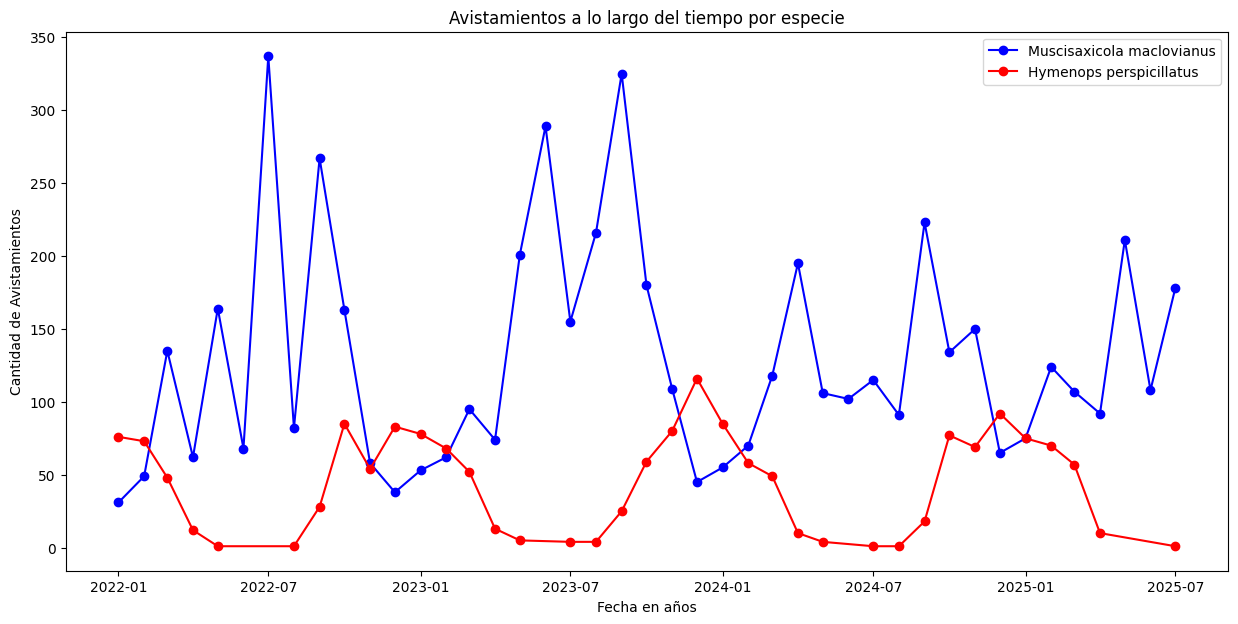

In [57]:
# Respuesta
# asumo que, puesto que se hacen los graficos para dataframes, este debe de ser de puntos, y no como un geodataframe
#ademas se leyo la documentacion oficial de pandas, las paginas especificas estan en el readme

dataframe_graficos = pd.concat([dormilona , runrun])

datos_grafico = dataframe_graficos.groupby(['sciName', 'year-month'])['howMany'].sum().reset_index()

datos_grafico = datos_grafico.sort_values(by='year-month')

colore = {'Muscisaxicola maclovianus': 'blue','Hymenops perspicillatus': 'red'} #c-h-i chi 

#dataframe_graficos2[dataframe_graficos2["sciName"] == "Hymenops perspicillatus"].head()

fig, ax = plt.subplots(figsize=(15, 7))

#iteramos en los datos ordenados por yearmonth, para recorrer los datos para graficarlo
for i, j in colore.items():
    subset = datos_grafico[datos_grafico['sciName'] == i]
    ax.plot(subset['year-month'], subset['howMany'] , marker = "o" , linestyle='-', color=j, label = i)

ax.set_title('Avistamientos a lo largo del tiempo por especie')
ax.set_xlabel('Fecha en años')
ax.set_ylabel('Cantidad de Avistamientos')
ax.legend()

plt.show()


## Respuesta -->

La variacion entre ambas especies es curiosa, puesto que, los picos de la especie dormilona son justo en los minimos de runrun, además, se nota una clara tendencia a tener mas aves de la especie dormilona, es decir, por lo que se puede analizar de los graficos, se nota mayor número de aves de la especie dormilona en comparacion con la especie de runrun, su principal diferencia, es, como se mencionó anteriormente, que se nota una tendencia a que, cuando una especie este en su "pico" la otra está "en el suelo" como si mantuvieran una relación inversamente proporcional en cierto aspecto (son comparaciones, con los datos expuestos no se pueden hacer afirmaciones de ese estilo y que sea preciso, hay que recordar que correlacion no implica causalidad).

**b) (1 pto)** Grafique en un mapa de Chile la ubicación de cada avistamiento para cada especie mencionada por separado. Utilice el color de cada punto como indicador del mes de avistamiento (columna `month`). Para esto, utilice un **colormap cíclico** para representar los meses del año. Puede utilizar el colormap disponible en la siguiente celda, o bien utilizar otro (siempre y cuando sea cíclico).

In [58]:
import matplotlib.colors as mcolors
colors = ["coral", "blue", "coral"]
positions = [0, 0.5, 1]

# Creamos un colormap cíclico para representar meses del año
custom_cmap = mcolors.LinearSegmentedColormap.from_list("cyclic_cmap", list(zip(positions, colors)))

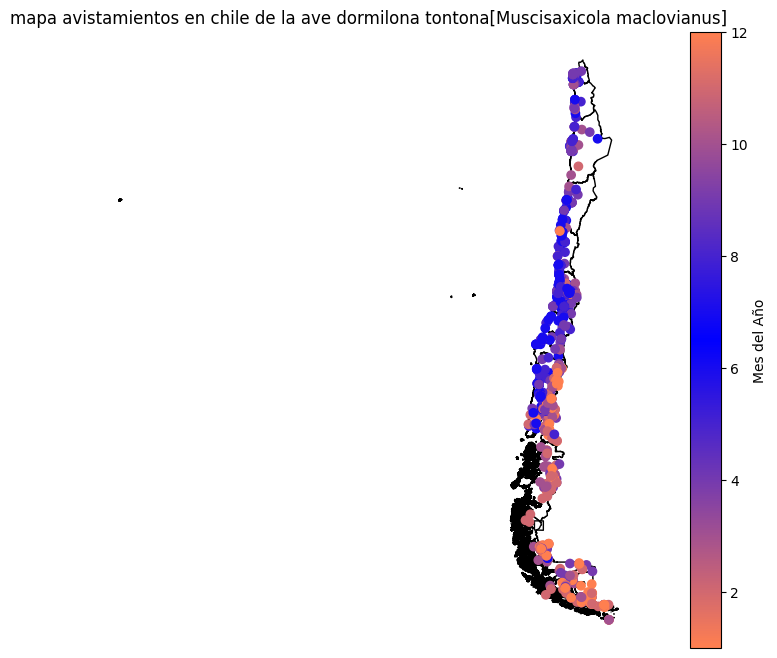

In [59]:
# Respuesta
datos_graf = geodatos[(geodatos["sciName"] == "Muscisaxicola maclovianus")]
column = datos_graf["month"]

fig , ax = plt.subplots(1 , 1 , figsize = (12, 8))


regional.plot(ax = ax , color = "none",  edgecolor= "black")
ax.set_title("mapa avistamientos en chile de la ave dormilona tontona[Muscisaxicola maclovianus]")

datos_graf.plot( column = column , cmap = custom_cmap , legend = True ,   ax = ax)

cbar = fig.axes[-1]
cbar.set_ylabel("Mes del Año")
ax.set_axis_off()
plt.show()  




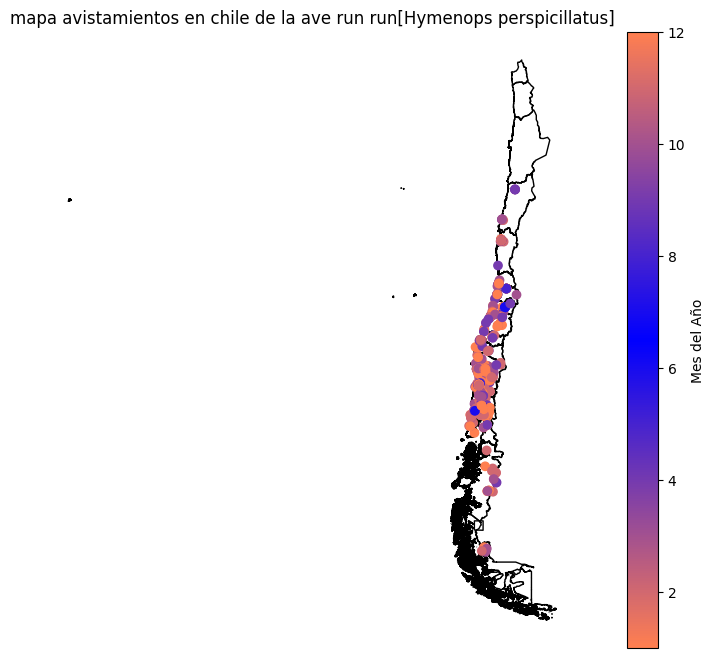

In [60]:
datos_graf2 = geodatos[(geodatos["sciName"] == "Hymenops perspicillatus")]

#se uso IA para el desarollo del grafico , aqui el link [https://g.co/gemini/share/e3f5ec58c6f3]


column = datos_graf2["month"]

fig , ax = plt.subplots(1 , 1 , figsize = (12, 8))


regional.plot(ax = ax , color = "none",  edgecolor= "black")
ax.set_title("mapa avistamientos en chile de la ave run run[Hymenops perspicillatus]")
ax.set_ylabel("Color acorde a cada mes del año")

#en caso de que se considere de alguna manera "molesto" el mapa de chile, en ambos graficos es cuestion de unicamente
#poner un "#" en regional , informo puesto que parte de los puntos y como se mueven las aves se ven de mejor manera 
#de esta forma

datos_graf2.plot( column = column , cmap = custom_cmap , legend = True ,  ax = ax)

cbar = fig.axes[-1]
cbar.set_ylabel("Mes del Año")
ax.set_axis_off()
plt.show()


**c) (0.5 pts)** Describa las migraciones de estas dos especies. ¿Cómo se diferencian?

Respuesta

Por como se ve en el gráfico, ambas aves poseen patrones de migracion distintos, las aves runrun (Hymenops perspicillatus) poseen un patron de migración menos marcado, por lo que se puede analizar de la grafica se está moviendo de forma "local" es decir, se mueve dentro de una misma region o sus cercanías , con varianzas estadísticas de aves que van a otros lugares, u, que en esta zona por otras razones solo se analicen las aves en estaciones específicas, esto difiere de lo que se puede ver de la ave dormilona (Muscisaxicola maclovianus) la cual presenta, por lo que se puede analizar de los graficos, un claro patrón de migración, moviendose a lo largo del pais entre estaciones, con ayuda de la gradiente, podemos decir, que el transporte se hace para ir al desierto cuando empieza o esta por empezar el invierno.

# Aclaracion Importante leer

En varias partes del codigo menciono el readme, esto asumiendo que sera revisado desde el github , en caso de no ser asi, este es mi github y el link directo a la tarea

#### github: [https://github.com/esteban78009/IMT2200-Esteban-Cortes]
#### Tarea: [https://github.com/esteban78009/IMT2200-Esteban-Cortes/tree/main/tareas/tarea%2002]